# Milestone 3 — Performance Analysis
**Random Forest: M1 (CPU) vs M2 (CPU+GPU, 1 tree) vs M3 (CPU+GPU, 10 trees)**
**M3 training variants: Sequential | Mutex-Parallel | CUDA Streams**

All CSVs use **seconds** as the time unit. No conversion needed.

## Section 0 — Upload CSVs

In [1]:
from google.colab import files
print("Upload all CSVs (M1, M2, M3) at once when prompted:")
uploaded = files.upload()

Upload all CSVs (M1, M2, M3) at once when prompted:


Saving benchmark_forest_train_m3_cpu.csv to benchmark_forest_train_m3_cpu (1).csv
Saving benchmark_forest_train_m3_sec.csv to benchmark_forest_train_m3_sec (1).csv
Saving benchmark_metrics_m1.csv to benchmark_metrics_m1 (1).csv
Saving benchmark_metrics_m2.csv to benchmark_metrics_m2 (1).csv
Saving benchmark_scalability_m1.csv to benchmark_scalability_m1 (1).csv
Saving benchmark_scalability_m2.csv to benchmark_scalability_m2 (1).csv
Saving benchmark_scalability_m3_sec.csv to benchmark_scalability_m3_sec (1).csv
Saving benchmark_speedup_vs_trees_m3_sec.csv to benchmark_speedup_vs_trees_m3_sec (1).csv
Saving benchmark_throughput_m3_sec.csv to benchmark_throughput_m3_sec (1).csv
Saving cpu_vs_gpu_comparison.csv to cpu_vs_gpu_comparison (1).csv


## Section 1 — Load All CSVs

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# ── Colour palette (consistent across all plots) ───────────────────────────
C_M1  = '#4472C4'   # blue   — M1 CPU Sequential
C_M2  = '#ED7D31'   # orange — M2 CPU+GPU (1 tree)
C_SEQ = '#70AD47'   # green  — M3 Sequential (10 trees)
C_MTX = '#FFC000'   # amber  — M3 Mutex
C_STR = '#FF0000'   # red    — M3 Streams
C_PS  = '#7030A0'   # purple — Parallel-samples inference
C_PT  = '#00B0F0'   # cyan   — Parallel-trees inference

# ── Dataset labels ─────────────────────────────────────────────────────────
DS_FULL  = ['Iris','Shuttle','LetterRecognition','Skin_NonSkin','Synthetic_1M_200f']
DS_SHORT = ['Iris','Shuttle','Letter','Skin','Synth-1M']
DS_MAP   = dict(zip(DS_FULL, DS_SHORT))


def read_csv_any(filename):
    for candidate in [Path(filename), Path('csvs') / filename]:
        if candidate.exists():
            return pd.read_csv(candidate)
    raise FileNotFoundError(f'Could not find {filename} in the workspace root or csvs/')

# ── M1 ─────────────────────────────────────────────────────────────────────
m1 = read_csv_any('benchmark_metrics_m1.csv')
m1['dataset'] = m1['dataset'].replace({'Synthetic_dataset_1000k_200f': 'Synthetic_1M_200f'})
m1_scale = read_csv_any('benchmark_scalability_m1.csv')
# M1 dataset name column is 'dataset'; rename to match DS_FULL
m1['ds_short'] = m1['dataset'].map(DS_MAP)

# ── M1 vs M2 summary ──────────────────────────────────────────────────────
m1m2 = read_csv_any('cpu_vs_gpu_comparison.csv')
# columns: Dataset, CPU_Time (sec), GPU_Time (sec), Speedup (CPU/GPU), CPU_Accuracy (%), GPU_Accuracy (%)

# ── M2 ─────────────────────────────────────────────────────────────────────
m2 = read_csv_any('benchmark_metrics_m2.csv')
m2['dataset'] = m2['dataset'].replace({'Synthetic_dataset_1000k_200f': 'Synthetic_1M_200f'})
m2_scale = read_csv_any('benchmark_scalability_m2.csv')
m2['ds_short'] = m2['dataset'].map(DS_MAP)

# ── M3 ─────────────────────────────────────────────────────────────────────
m3_train  = read_csv_any('benchmark_forest_train_m3_sec.csv')
m3_scale  = read_csv_any('benchmark_scalability_m3_sec.csv')
m3_tput   = read_csv_any('benchmark_throughput_m3_sec.csv')
m3_svt    = read_csv_any('benchmark_speedup_vs_trees_m3_sec.csv')

m3_train['ds_short'] = m3_train['dataset'].map(DS_MAP).fillna(m3_train['dataset'])
m3_scale['ds_short'] = m3_scale['dataset'].map(DS_MAP).fillna(m3_scale['dataset'])
m3_svt['ds_short']   = m3_svt['dataset'].map(DS_MAP).fillna(m3_svt['dataset'])

# Split M3 train into variant sub-frames (aligned to DS_FULL order)
def get_var(df, v):
    sub = df[df['variant']==v].copy()
    sub = sub.set_index('dataset').reindex(DS_FULL).reset_index()
    return sub

m3_seq  = get_var(m3_train, 'Sequential')
m3_mtx  = get_var(m3_train, 'Mutex')
m3_str  = get_var(m3_train, 'Streams')

# Parse throughput dataset label  (format: "DatasetName | Variant label")
m3_tput['ds']       = m3_tput['variant'].str.split(r'\s\|\s', n=1).str[0].str.strip()
m3_tput['inf_var']  = m3_tput['variant'].str.split(r'\s\|\s', n=1).str[1].str.strip()
m3_tput['ds_short'] = m3_tput['ds'].map(DS_MAP).fillna(m3_tput['ds'])

# Filter each inference variant, sort to DS_FULL order (no reindex — avoids NaN on column data)
def get_tput(keyword):
    sub = m3_tput[m3_tput['inf_var'].str.contains(keyword, case=False, na=False)].copy()
    sub['_order'] = sub['ds'].map({d: i for i, d in enumerate(DS_FULL)})
    return sub.sort_values('_order').drop(columns='_order').reset_index(drop=True)

tput_seq_inf = get_tput('baseline')
tput_par_s   = get_tput('samples')
tput_par_t   = get_tput('trees')

# Verify all 5 datasets parsed correctly
print("Throughput rows per variant:", len(tput_seq_inf), len(tput_par_s), len(tput_par_t))
print("Datasets found:", tput_seq_inf['ds'].tolist())

print("All CSVs loaded successfully.")
print(f"M1: {len(m1)} rows | M2: {len(m2)} rows | M3 train: {len(m3_train)} rows")
print(f"M3 scalability: {len(m3_scale)} rows | M3 throughput: {len(m3_tput)} rows | M3 K-trees: {len(m3_svt)} rows")

Throughput rows per variant: 5 5 5
Datasets found: ['Iris', 'Shuttle', 'LetterRecognition', 'Skin_NonSkin', 'Synthetic_1M_200f']
All CSVs loaded successfully.
M1: 5 rows | M2: 5 rows | M3 train: 15 rows
M3 scalability: 60 rows | M3 throughput: 15 rows | M3 K-trees: 25 rows


## Section 2 — M1 vs M2: Single-Tree Training Speedup
*Reproduces the M2 analysis notebook comparison using the cpu_vs_gpu_comparison.csv.*

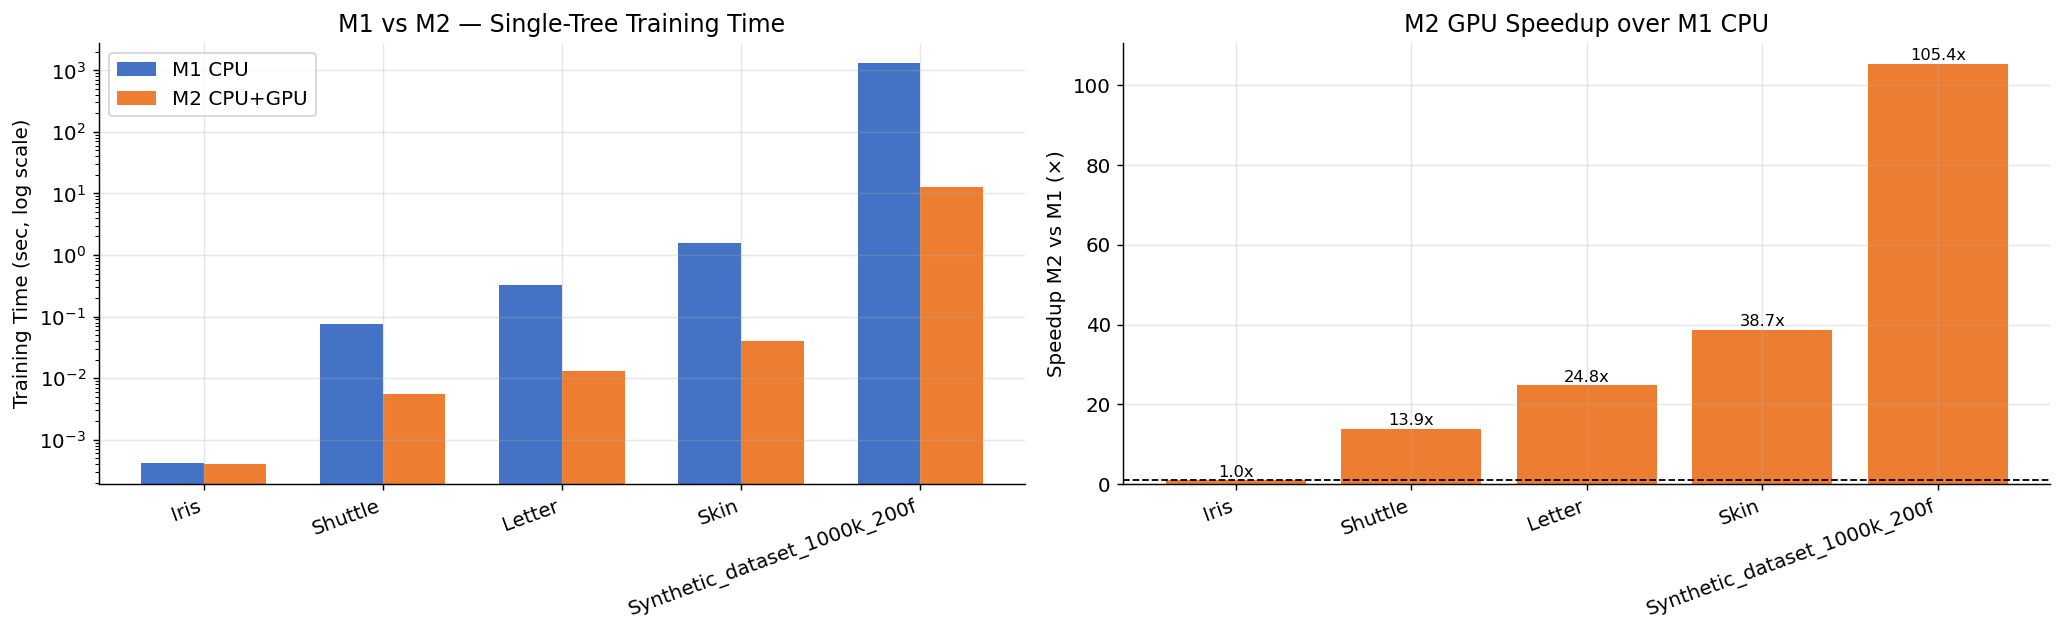

Saved: plot_m1_vs_m2_speedup.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(m1m2))
labels = [DS_MAP.get(d, d) for d in m1m2['Dataset']]

# Training time side-by-side
ax = axes[0]
w = 0.35
ax.bar(x - w/2, m1m2['CPU_Time (sec)'], width=w, label='M1 CPU',     color=C_M1)
ax.bar(x + w/2, m1m2['GPU_Time (sec)'], width=w, label='M2 CPU+GPU', color=C_M2)
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Training Time (sec, log scale)')
ax.set_title('M1 vs M2 — Single-Tree Training Time')
ax.legend()

# Speedup bar
ax2 = axes[1]
colors = [C_M2 if s > 1 else '#FF6B6B' for s in m1m2['Speedup (CPU/GPU)']]
bars = ax2.bar(x, m1m2['Speedup (CPU/GPU)'], color=colors)
ax2.axhline(1, color='black', linestyle='--', linewidth=1)
for bar, s in zip(bars, m1m2['Speedup (CPU/GPU)']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{s:.1f}x', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=20, ha='right')
ax2.set_ylabel('Speedup M2 vs M1 (×)')
ax2.set_title('M2 GPU Speedup over M1 CPU')

plt.tight_layout()
plt.savefig('plot_m1_vs_m2_speedup.png', bbox_inches='tight')
plt.show()
print("Saved: plot_m1_vs_m2_speedup.png")

## Section 3

Alignment OK — no NaN rows.


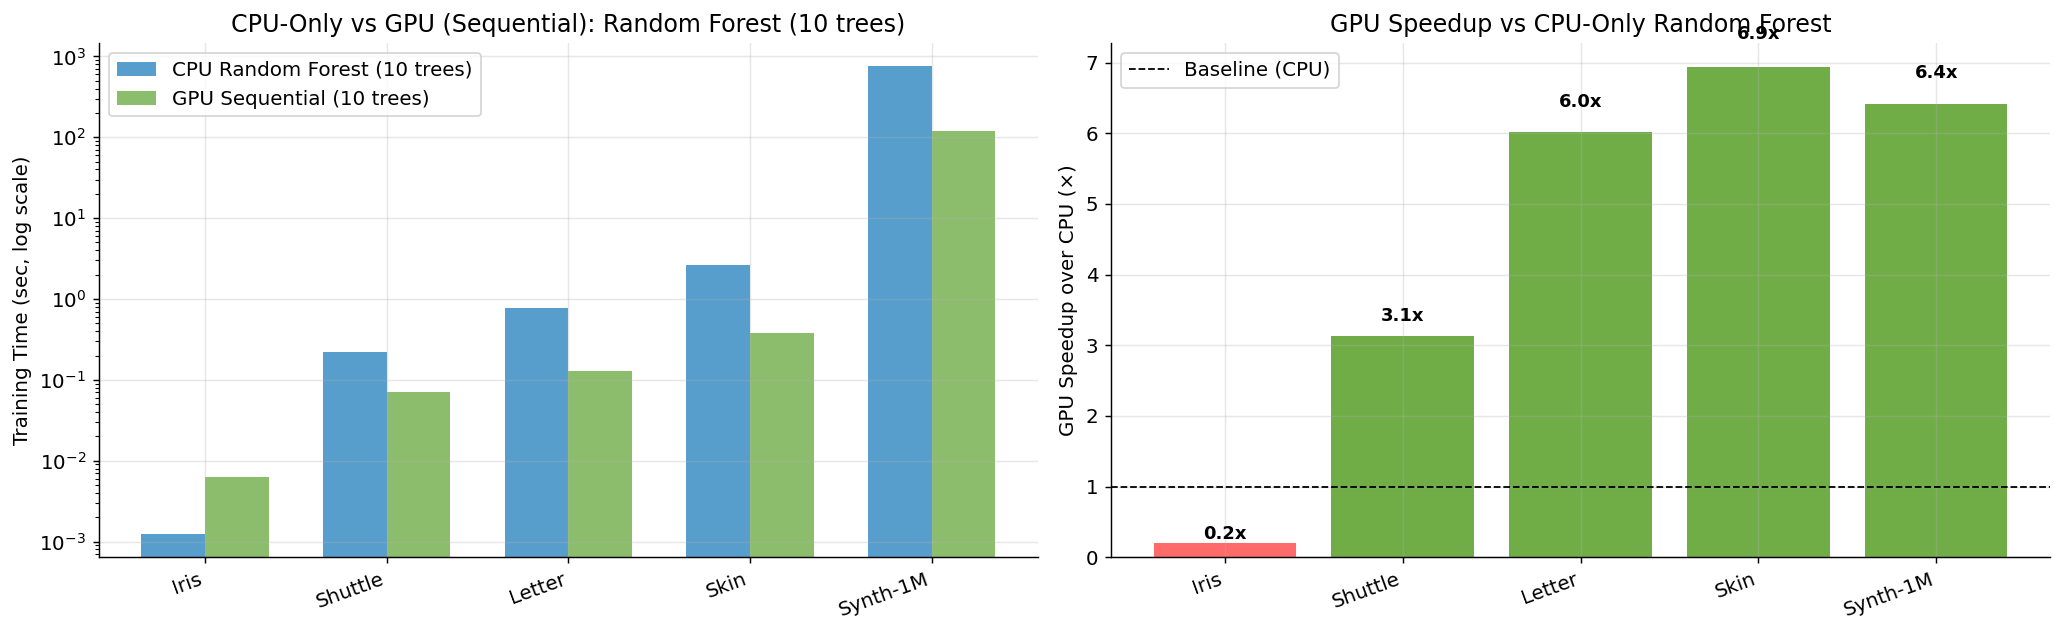

Saved: plot_cpu_vs_gpu_randomforest.png

=== CPU vs GPU Random Forest Speedup ===
 Dataset  CPU_10trees_sec  GPU_Seq_10trees_sec  Speedup_GPU_vs_CPU
    Iris           0.0012               0.0064                0.20
 Shuttle           0.2187               0.0699                3.13
  Letter           0.7714               0.1282                6.02
    Skin           2.6602               0.3836                6.93
Synth-1M         756.7100             118.0897                6.41

Saved: cpu_vs_gpu_speedup.csv


In [4]:
##  — CPU Random Forest vs GPU Random Forest (10 trees each)
# Directly addresses: "training time (CPU vs CPU–GPU)"

# Load CPU Random Forest results
cpu_rf_raw = pd.read_csv('benchmark_forest_train_m3_cpu.csv')

# Fix dataset name inconsistency: CPU CSV uses "Letter", notebook uses "LetterRecognition"
cpu_rf_raw['dataset'] = cpu_rf_raw['dataset'].replace({'Letter': 'LetterRecognition'})

# Align both to DS_FULL order
cpu_rf_aligned  = cpu_rf_raw.set_index('dataset').reindex(DS_FULL)
gpu_seq_aligned = m3_seq.set_index('dataset').reindex(DS_FULL)

# Sanity check — flag any NaN rows so you catch future mismatches early
nan_cpu = cpu_rf_aligned['train_time_sec'].isna().sum()
nan_gpu = gpu_seq_aligned['train_time_sec'].isna().sum()
if nan_cpu or nan_gpu:
    print(f"WARNING: {nan_cpu} NaN rows in CPU alignment, {nan_gpu} in GPU alignment")
    print("CPU datasets found:", cpu_rf_raw['dataset'].tolist())
    print("DS_FULL expected:", DS_FULL)
else:
    print("Alignment OK — no NaN rows.")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(DS_FULL))
w = 0.35

# Training time comparison (log scale)
ax = axes[0]
ax.bar(x - w/2, cpu_rf_aligned['train_time_sec'], width=w,
       label='CPU Random Forest (10 trees)', color='#2E86C1', alpha=0.8)
ax.bar(x + w/2, gpu_seq_aligned['train_time_sec'], width=w,
       label='GPU Sequential (10 trees)', color=C_SEQ, alpha=0.8)
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax.set_ylabel('Training Time (sec, log scale)')
ax.set_title('CPU-Only vs GPU (Sequential): Random Forest (10 trees)')
ax.legend()

# Speedup bar chart
ax2 = axes[1]
gpu_speedup = cpu_rf_aligned['train_time_sec'].values / gpu_seq_aligned['train_time_sec'].values
colors = [C_SEQ if s > 1 else '#FF6B6B' for s in gpu_speedup]
bars = ax2.bar(x, gpu_speedup, color=colors)
ax2.axhline(1, color='black', linestyle='--', linewidth=1, label='Baseline (CPU)')

for bar, s in zip(bars, gpu_speedup):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05 * max(bar.get_height(), 0.01),
             f'{s:.1f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax2.set_ylabel('GPU Speedup over CPU (×)')
ax2.set_title('GPU Speedup vs CPU-Only Random Forest')
ax2.legend()

plt.tight_layout()
plt.savefig('plot_cpu_vs_gpu_randomforest.png', bbox_inches='tight')
plt.show()
print("Saved: plot_cpu_vs_gpu_randomforest.png")

# Print speedup table
print("\n=== CPU vs GPU Random Forest Speedup ===")
speedup_df = pd.DataFrame({
    'Dataset':          DS_SHORT,
    'CPU_10trees_sec':  cpu_rf_aligned['train_time_sec'].values.round(4),
    'GPU_Seq_10trees_sec': gpu_seq_aligned['train_time_sec'].values.round(4),
    'Speedup_GPU_vs_CPU': gpu_speedup.round(2)
})
print(speedup_df.to_string(index=False))
speedup_df.to_csv('cpu_vs_gpu_speedup.csv', index=False)
print("\nSaved: cpu_vs_gpu_speedup.csv")


=== Cross-Milestone One-Tree Training Time ===
 Dataset  M1_1tree_sec  M2_1tree_sec  M3_Seq_avg_tree_sec  M3_Mutex_avg_tree_sec  M3_Streams_avg_tree_sec
    Iris      0.000420      0.000405             0.000610               0.003272                 0.003645
 Shuttle      0.076503      0.005504             0.006744               0.036894                 0.036237
  Letter      0.330630      0.013309             0.012555               0.068455                 0.072858
    Skin      1.564048      0.040398             0.035378               0.200112                 0.201750
Synth-1M   1324.446309     12.561294            11.790790              65.898764                64.729261

Saved: summary_cross_milestone_one_tree.csv


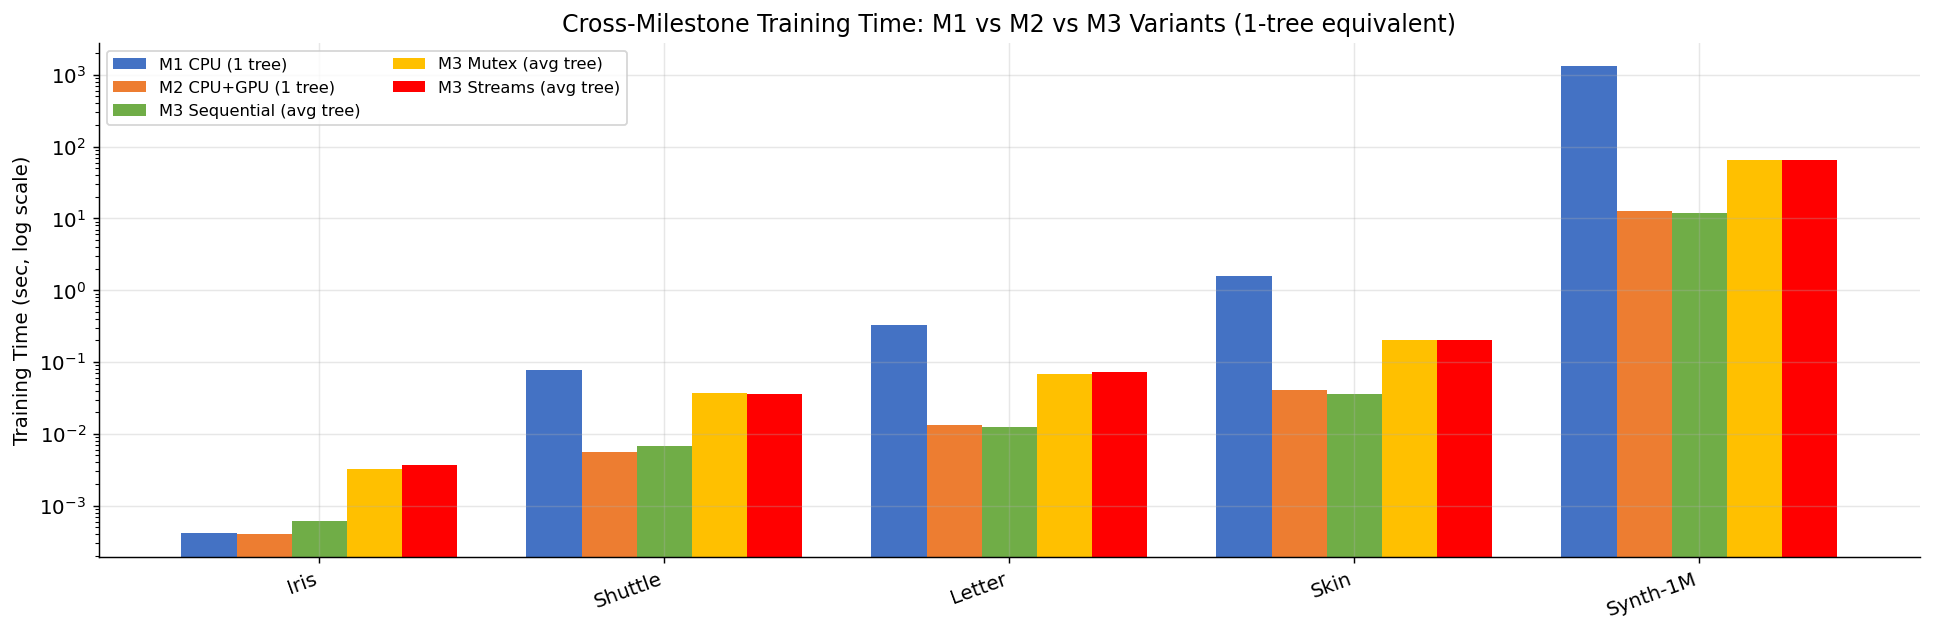

Saved: plot_cross_milestone_training.png


In [17]:
# Cross-milestone training time comparison for one tree equivalent
# M3 uses avg_tree_time_sec so the 10-tree forests can be compared on a per-tree basis.
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(DS_FULL))
w = 0.16

m1_t = m1.set_index('dataset').reindex(DS_FULL)['train_time_sec'].values
m2_t = m2.set_index('dataset').reindex(DS_FULL)['total_train_sec'].values
m3_seq_t = m3_seq.set_index('dataset').reindex(DS_FULL)['avg_tree_time_sec'].values
m3_mtx_t = m3_mtx.set_index('dataset').reindex(DS_FULL)['avg_tree_time_sec'].values
m3_str_t = m3_str.set_index('dataset').reindex(DS_FULL)['avg_tree_time_sec'].values

summary = pd.DataFrame({
    'Dataset': DS_SHORT,
    'M1_1tree_sec': m1_t.round(6),
    'M2_1tree_sec': m2_t.round(6),
    'M3_Seq_avg_tree_sec': m3_seq_t.round(6),
    'M3_Mutex_avg_tree_sec': m3_mtx_t.round(6),
    'M3_Streams_avg_tree_sec': m3_str_t.round(6),
})
print("=== Cross-Milestone One-Tree Training Time ===")
print(summary.to_string(index=False))
summary.to_csv('summary_cross_milestone_one_tree.csv', index=False)
print("\nSaved: summary_cross_milestone_one_tree.csv")

ax.bar(x - 2*w, m1_t,      width=w, label='M1 CPU (1 tree)',              color=C_M1)
ax.bar(x - 1*w, m2_t,      width=w, label='M2 CPU+GPU (1 tree)',          color=C_M2)
ax.bar(x + 0*w, m3_seq_t,  width=w, label='M3 Sequential (avg tree)',    color=C_SEQ)
ax.bar(x + 1*w, m3_mtx_t,  width=w, label='M3 Mutex (avg tree)',         color=C_MTX)
ax.bar(x + 2*w, m3_str_t,  width=w, label='M3 Streams (avg tree)',       color=C_STR)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax.set_ylabel('Training Time (sec, log scale)')
ax.set_title('Cross-Milestone Training Time: M1 vs M2 vs M3 Variants (1-tree equivalent)')
ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('plot_cross_milestone_training.png', bbox_inches='tight')
plt.show()
print('Saved: plot_cross_milestone_training.png')

## Section 4 — M3 Training Variants: Sequential vs Mutex vs Streams

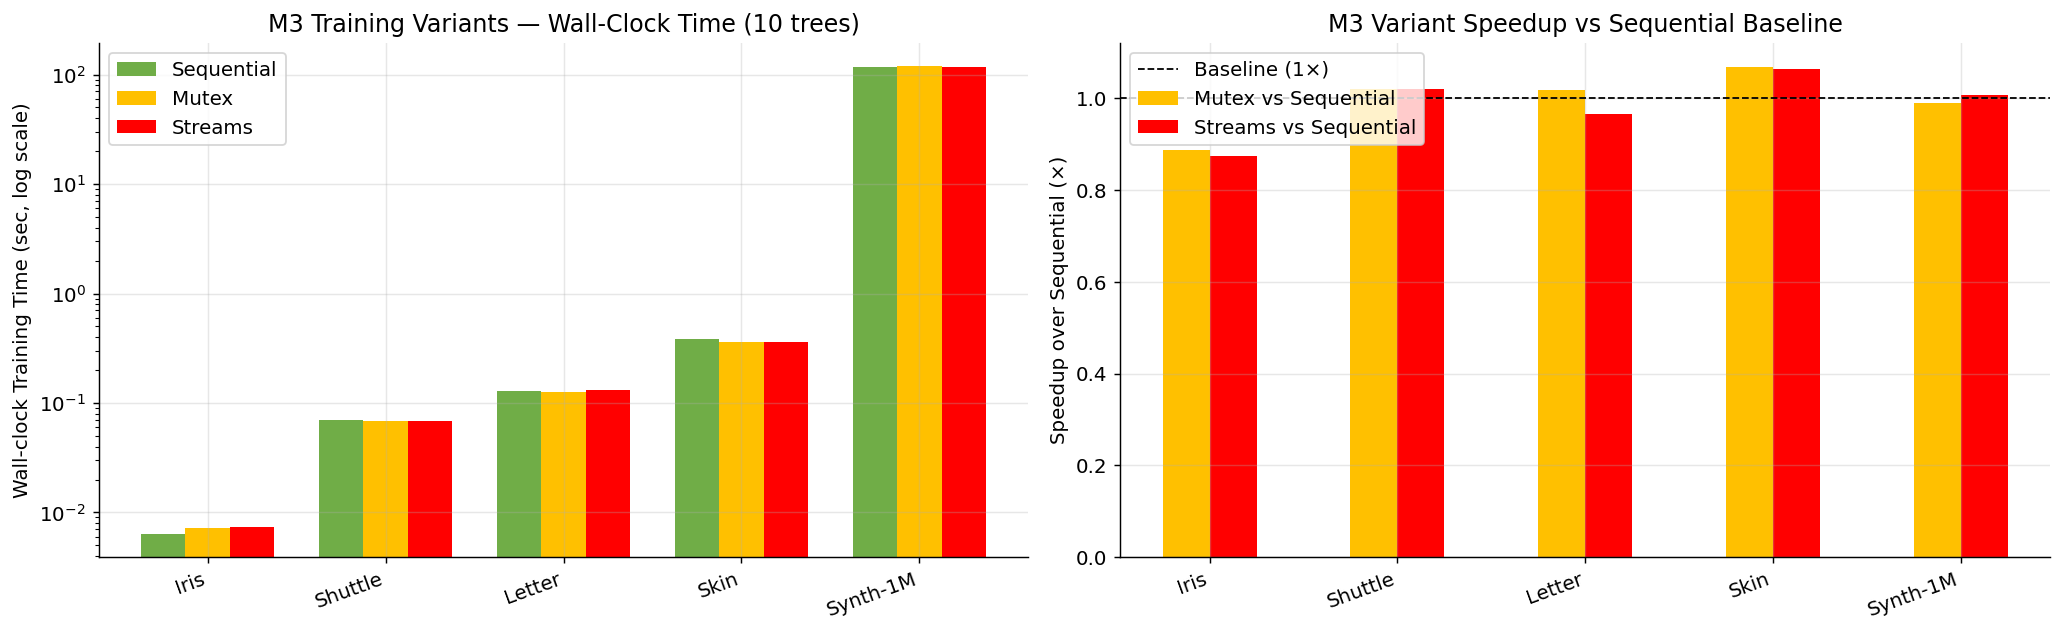

Saved: plot_m3_training_variants.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(DS_FULL))
w = 0.25

ax = axes[0]
ax.bar(x - w, m3_seq['train_time_sec'], width=w, label='Sequential', color=C_SEQ)
ax.bar(x,     m3_mtx['train_time_sec'], width=w, label='Mutex',      color=C_MTX)
ax.bar(x + w, m3_str['train_time_sec'], width=w, label='Streams',    color=C_STR)
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax.set_ylabel('Wall-clock Training Time (sec, log scale)')
ax.set_title('M3 Training Variants — Wall-Clock Time (10 trees)')
ax.legend()

mutex_speedup  = m3_seq['train_time_sec'].values / m3_mtx['train_time_sec'].values
stream_speedup = m3_seq['train_time_sec'].values / m3_str['train_time_sec'].values

ax2 = axes[1]
ax2.bar(x - w/2, mutex_speedup,  width=w, label='Mutex vs Sequential',  color=C_MTX)
ax2.bar(x + w/2, stream_speedup, width=w, label='Streams vs Sequential', color=C_STR)
ax2.axhline(1, color='black', linestyle='--', linewidth=1, label='Baseline (1×)')
ax2.set_xticks(x); ax2.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax2.set_ylabel('Speedup over Sequential (×)')
ax2.set_title('M3 Variant Speedup vs Sequential Baseline')
ax2.legend()

plt.tight_layout()
plt.savefig('plot_m3_training_variants.png', bbox_inches='tight')
plt.show()
print("Saved: plot_m3_training_variants.png")

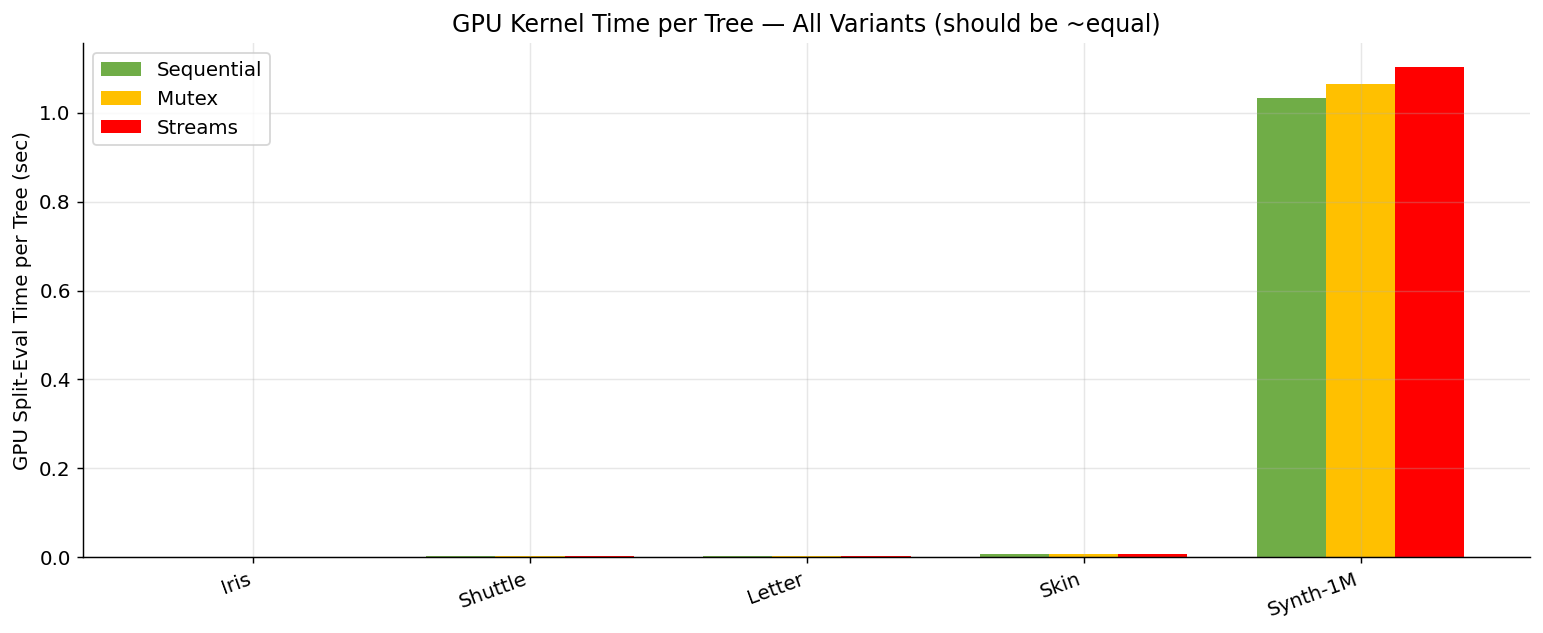

Saved: plot_m3_gpu_time_per_tree.png


In [6]:
# GPU kernel time per tree — confirms GPU work is constant across variants
fig, ax = plt.subplots(figsize=(12, 5))
w = 0.25
gpu_seq = m3_seq['gpu_kernel_time_sec'] / 10
gpu_mtx = m3_mtx['gpu_kernel_time_sec'] / 10
gpu_str = m3_str['gpu_kernel_time_sec'] / 10

ax.bar(x - w, gpu_seq, width=w, label='Sequential', color=C_SEQ)
ax.bar(x,     gpu_mtx, width=w, label='Mutex',      color=C_MTX)
ax.bar(x + w, gpu_str, width=w, label='Streams',    color=C_STR)
ax.set_xticks(x); ax.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax.set_ylabel('GPU Split-Eval Time per Tree (sec)')
ax.set_title('GPU Kernel Time per Tree — All Variants (should be ~equal)')
ax.legend()

plt.tight_layout()
plt.savefig('plot_m3_gpu_time_per_tree.png', bbox_inches='tight')
plt.show()
print("Saved: plot_m3_gpu_time_per_tree.png")

## Section 5 — Inference Throughput: Sequential vs Parallel-Samples vs Parallel-Trees

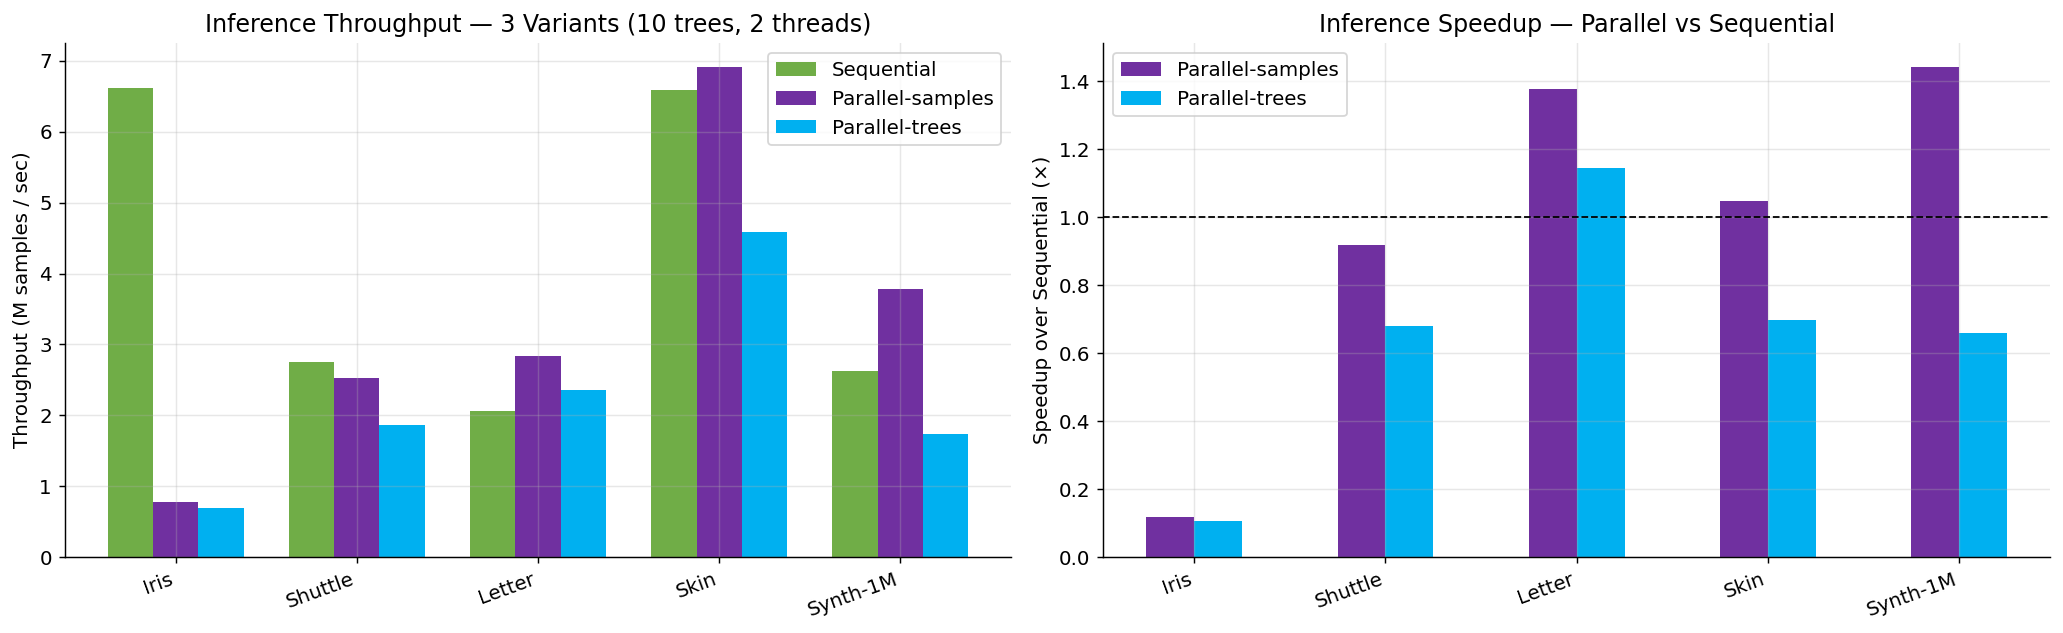

Saved: plot_m3_inference_throughput.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x  = np.arange(len(DS_FULL))
w  = 0.25

ax = axes[0]
ax.bar(x - w, tput_seq_inf['samples_per_sec']/1e6, width=w, label='Sequential',         color=C_SEQ)
ax.bar(x,     tput_par_s['samples_per_sec']/1e6,   width=w, label='Parallel-samples',   color=C_PS)
ax.bar(x + w, tput_par_t['samples_per_sec']/1e6,   width=w, label='Parallel-trees',     color=C_PT)
ax.set_xticks(x); ax.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax.set_ylabel('Throughput (M samples / sec)')
ax.set_title('Inference Throughput — 3 Variants (10 trees, 2 threads)')
ax.legend()

ax2 = axes[1]
ax2.bar(x - w/2, tput_par_s['speedup'], width=w, label='Parallel-samples', color=C_PS)
ax2.bar(x + w/2, tput_par_t['speedup'], width=w, label='Parallel-trees',   color=C_PT)
ax2.axhline(1, color='black', linestyle='--', linewidth=1)
ax2.set_xticks(x); ax2.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax2.set_ylabel('Speedup over Sequential (×)')
ax2.set_title('Inference Speedup — Parallel vs Sequential')
ax2.legend()

plt.tight_layout()
plt.savefig('plot_m3_inference_throughput.png', bbox_inches='tight')
plt.show()
print("Saved: plot_m3_inference_throughput.png")

## Section 6 — Inference Speedup vs Number of Trees (K)

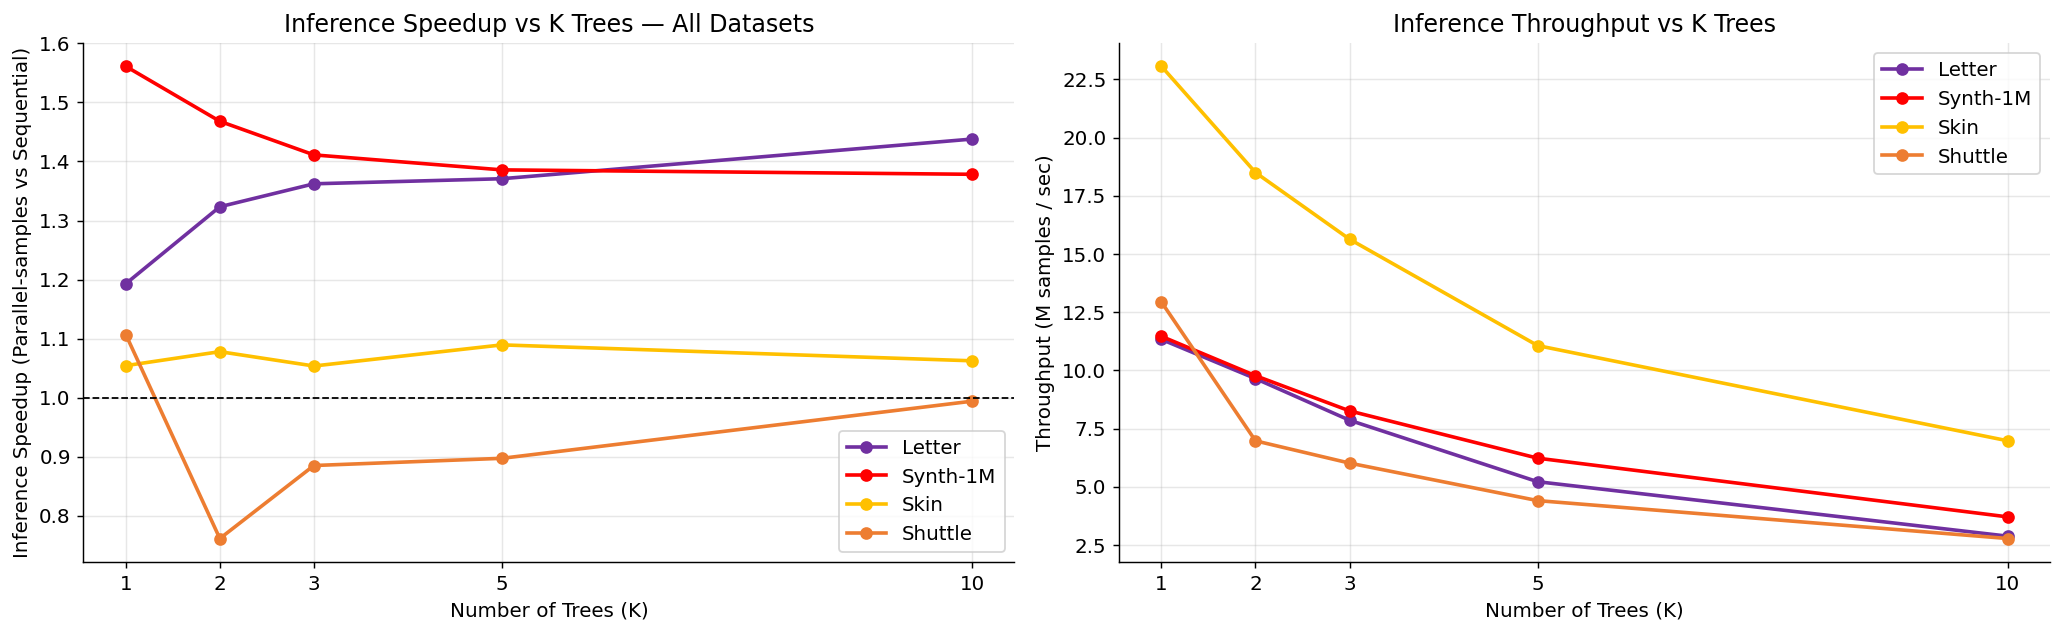

Saved: plot_m3_speedup_vs_k_trees.png


In [8]:
# One line per dataset showing how parallel-samples speedup changes with K
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_ds = ['LetterRecognition', 'Synthetic_1M_200f', 'Skin_NonSkin', 'Shuttle']
colors_svt = {'LetterRecognition': C_PS, 'Synthetic_1M_200f': C_STR,
              'Skin_NonSkin': C_MTX, 'Shuttle': C_M2}

ax = axes[0]
for ds in plot_ds:
    sub = m3_svt[m3_svt['dataset'] == ds]
    if sub.empty: continue
    ax.plot(sub['n_trees'], sub['speedup'], 'o-', label=DS_MAP.get(ds, ds),
            color=colors_svt[ds], linewidth=2, markersize=6)
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Number of Trees (K)')
ax.set_ylabel('Inference Speedup (Parallel-samples vs Sequential)')
ax.set_title('Inference Speedup vs K Trees — All Datasets')
ax.set_xticks([1,2,3,5,10])
ax.legend()

ax2 = axes[1]
for ds in plot_ds:
    sub = m3_svt[m3_svt['dataset'] == ds]
    if sub.empty: continue
    ax2.plot(sub['n_trees'], sub['throughput_sps']/1e6, 'o-',
             label=DS_MAP.get(ds, ds), color=colors_svt[ds], linewidth=2, markersize=6)
ax2.set_xlabel('Number of Trees (K)')
ax2.set_ylabel('Throughput (M samples / sec)')
ax2.set_title('Inference Throughput vs K Trees')
ax2.set_xticks([1,2,3,5,10])
ax2.legend()

plt.tight_layout()
plt.savefig('plot_m3_speedup_vs_k_trees.png', bbox_inches='tight')
plt.show()
print("Saved: plot_m3_speedup_vs_k_trees.png")

## Section 7 — N-Sample Scalability: All 3 M3 Variants

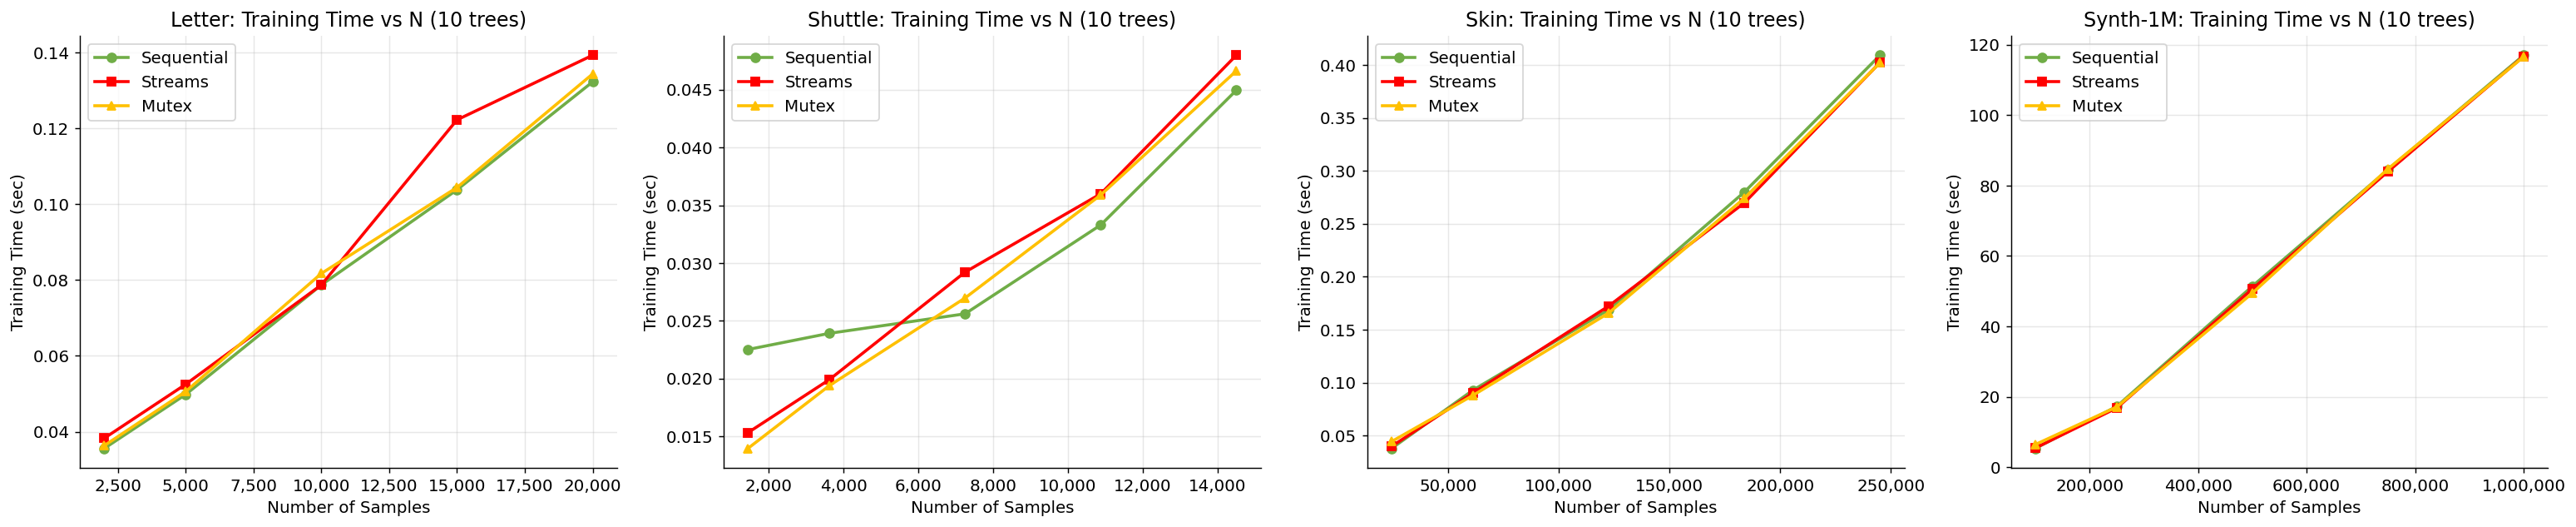

Saved: plot_m3_scalability_variants.png


In [9]:
# One plot per dataset with all 3 variants as lines
scale_ds = sorted(m3_scale['dataset'].unique())
n_plots  = len(scale_ds)
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5), squeeze=False)
axes = axes[0]

var_style = {
    'Sequential': (C_SEQ, 'o-'),
    'Streams':    (C_STR, 's-'),
    'Mutex':      (C_MTX, '^-'),
}

for i, ds in enumerate(scale_ds):
    ax = axes[i]
    for var, (col, marker) in var_style.items():
        sub = m3_scale[(m3_scale['dataset']==ds) & (m3_scale['variant']==var)].sort_values('n_samples')
        if not sub.empty:
            ax.plot(sub['n_samples'], sub['train_time_sec'], marker,
                    color=col, linewidth=2, markersize=6, label=var)
    ax.set_xlabel('Number of Samples')
    ax.set_ylabel('Training Time (sec)')
    ax.set_title(f'{DS_MAP.get(ds,ds)}: Training Time vs N (10 trees)')
    ax.legend()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

plt.tight_layout()
plt.savefig('plot_m3_scalability_variants.png', bbox_inches='tight')
plt.show()
print("Saved: plot_m3_scalability_variants.png")

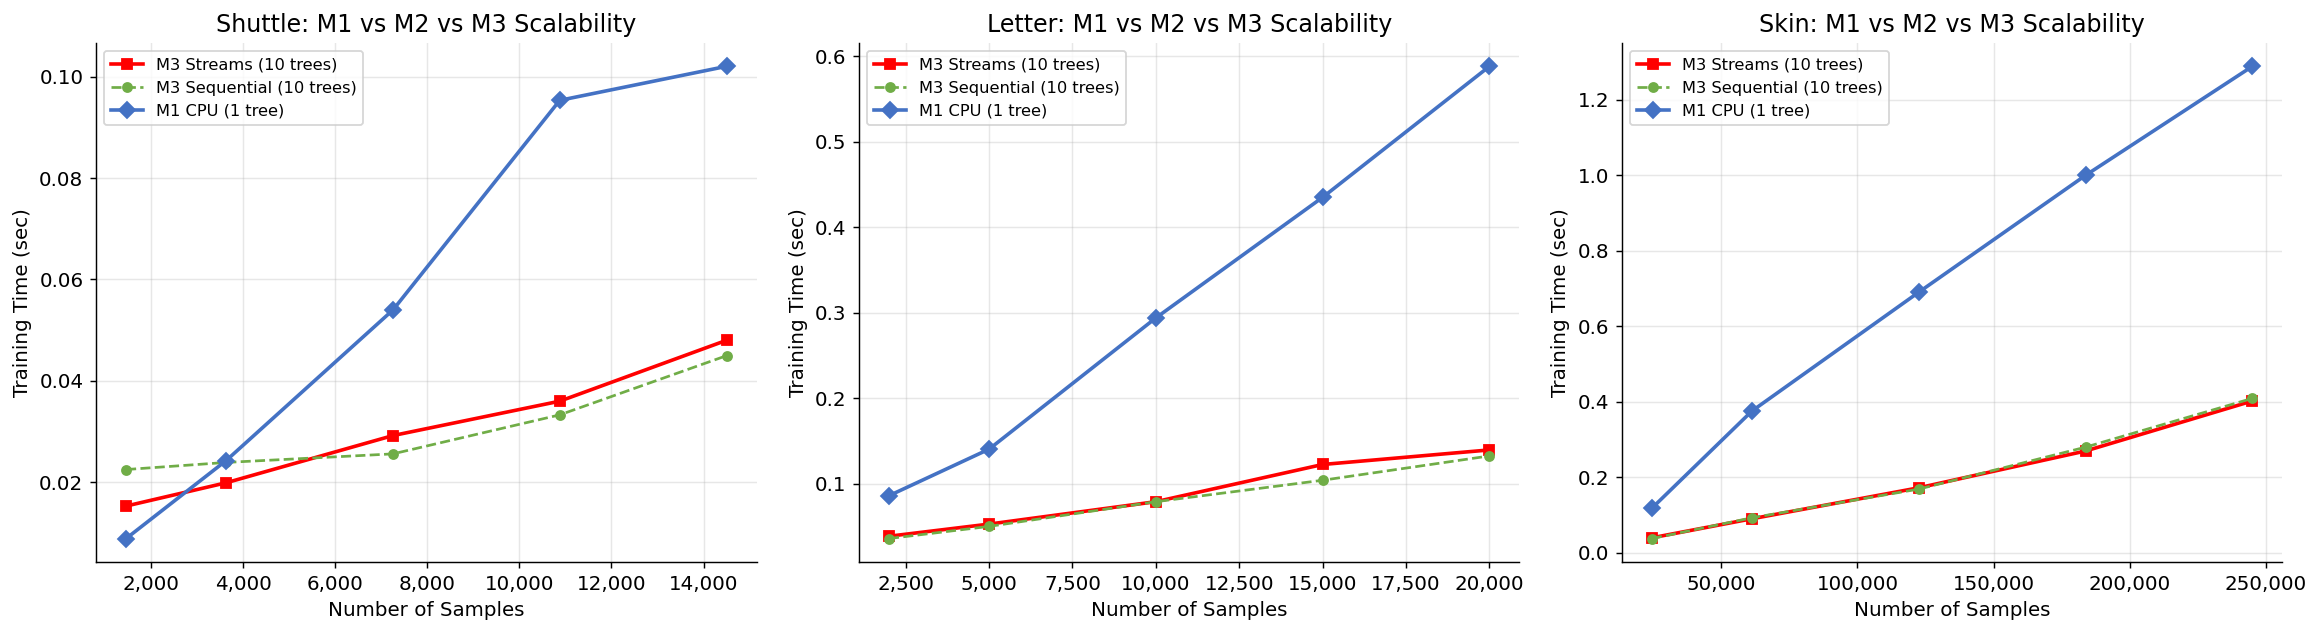

Saved: plot_cross_milestone_scalability.png


In [10]:
# Cross-milestone scalability: M1 vs M2 vs M3-Streams on shared datasets
# M1 column: train_time_sec, M2 column: total_train_sec
shared_ds = ['Shuttle', 'LetterRecognition', 'Skin_NonSkin']
n = len(shared_ds)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5), squeeze=False)
axes = axes[0]

for i, ds in enumerate(shared_ds):
    ax = axes[i]
    short = DS_MAP.get(ds, ds)

    # M3 Streams
    sub3 = m3_scale[(m3_scale['dataset']==ds) & (m3_scale['variant']=='Streams')].sort_values('n_samples')
    if not sub3.empty:
        ax.plot(sub3['n_samples'], sub3['train_time_sec'], 's-', color=C_STR,
                linewidth=2, markersize=6, label='M3 Streams (10 trees)')

    # M3 Sequential
    sub3s = m3_scale[(m3_scale['dataset']==ds) & (m3_scale['variant']=='Sequential')].sort_values('n_samples')
    if not sub3s.empty:
        ax.plot(sub3s['n_samples'], sub3s['train_time_sec'], 'o--', color=C_SEQ,
                linewidth=1.5, markersize=5, label='M3 Sequential (10 trees)')

    # M2
    sub2 = m2_scale[m2_scale['dataset']==ds].sort_values('n_samples')
    if not sub2.empty:
        ax.plot(sub2['n_samples'], sub2['total_train_sec'], '^-', color=C_M2,
                linewidth=2, markersize=6, label='M2 CPU+GPU (1 tree)')

    # M1
    sub1 = m1_scale[m1_scale['dataset']==ds].sort_values('n_samples')
    if not sub1.empty:
        ax.plot(sub1['n_samples'], sub1['train_time_sec'], 'D-', color=C_M1,
                linewidth=2, markersize=6, label='M1 CPU (1 tree)')

    ax.set_xlabel('Number of Samples')
    ax.set_ylabel('Training Time (sec)')
    ax.set_title(f'{short}: M1 vs M2 vs M3 Scalability')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

plt.tight_layout()
plt.savefig('plot_cross_milestone_scalability.png', bbox_inches='tight')
plt.show()
print("Saved: plot_cross_milestone_scalability.png")

## Section 8 — Accuracy: M1 vs M2 vs M3

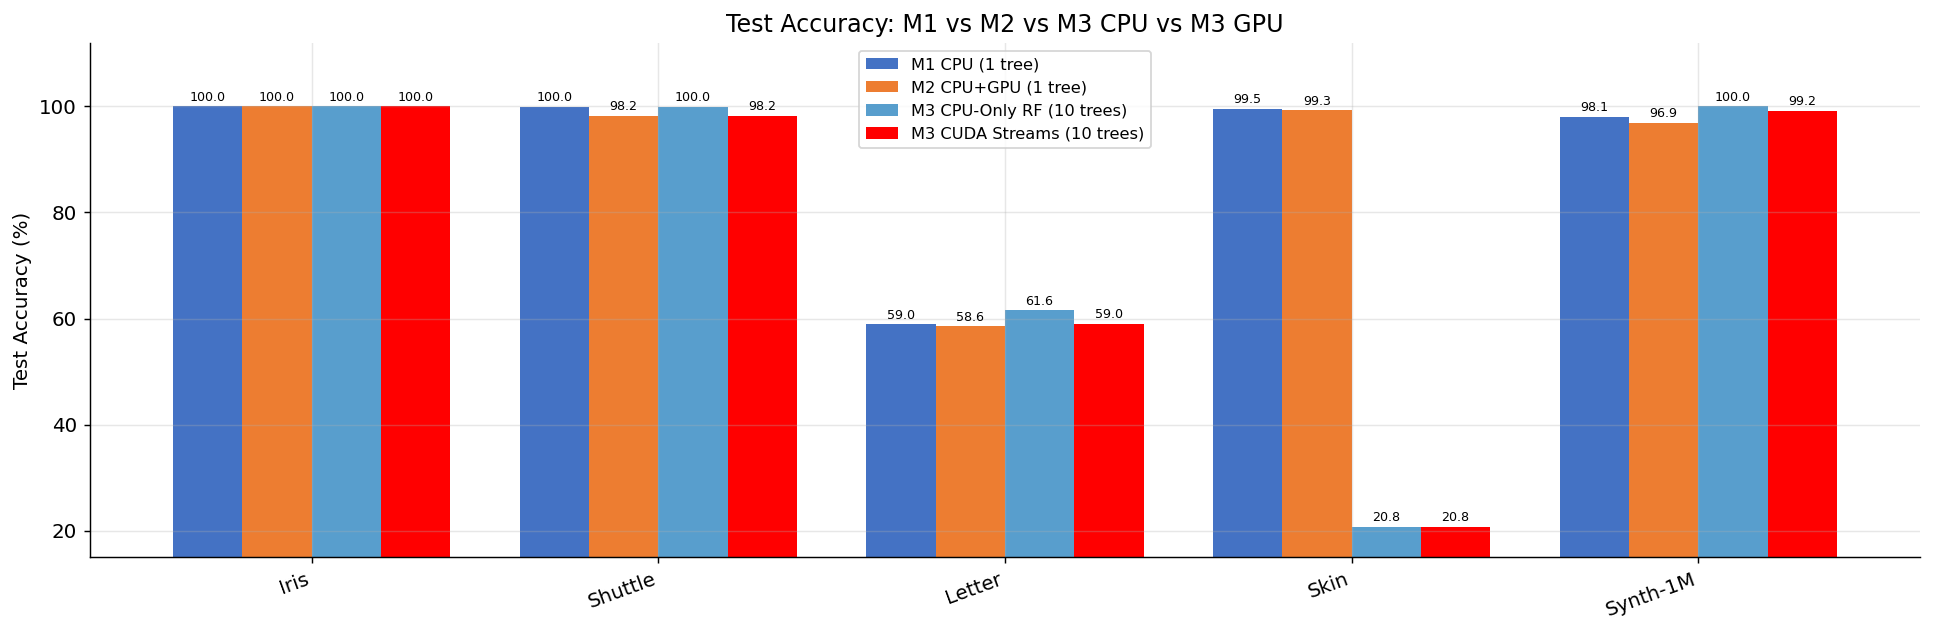

Saved: plot_accuracy_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(DS_FULL))
w = 0.2

m1_acc   = m1.set_index('dataset').reindex(DS_FULL)['test_accuracy'].values * 100
m2_acc   = m2.set_index('dataset').reindex(DS_FULL)['test_accuracy'].values * 100
m3_acc   = m3_str.set_index('dataset').reindex(DS_FULL)['test_accuracy'].values * 100
cpu_acc  = cpu_rf_aligned['test_accuracy'].values * 100

ax.bar(x - 1.5*w, m1_acc,  width=w, label='M1 CPU (1 tree)',              color=C_M1)
ax.bar(x - 0.5*w, m2_acc,  width=w, label='M2 CPU+GPU (1 tree)',           color=C_M2)
ax.bar(x + 0.5*w, cpu_acc, width=w, label='M3 CPU-Only RF (10 trees)',      color='#2E86C1', alpha=0.8)
ax.bar(x + 1.5*w, m3_acc,  width=w, label='M3 CUDA Streams (10 trees)',     color=C_STR)

ax.set_xticks(x); ax.set_xticklabels(DS_SHORT, rotation=20, ha='right')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(15, 112)
ax.set_title('Test Accuracy: M1 vs M2 vs M3 CPU vs M3 GPU')
ax.legend(fontsize=9)

for bar in ax.patches:
    h = bar.get_height()
    if h > 20:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('plot_accuracy_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: plot_accuracy_comparison.png")


## Section 9 — Summary Tables

In [12]:
# Cross-milestone training time and accuracy summary
m1_t = m1.set_index('dataset').reindex(DS_FULL)['train_time_sec'].values
m2_t = m2.set_index('dataset').reindex(DS_FULL)['total_train_sec'].values
m3_s = m3_seq['train_time_sec'].values
m3_r = m3_str['train_time_sec'].values

summary = pd.DataFrame({
    'Dataset':             DS_SHORT,
    'M1_train_sec':        m1_t.round(4),
    'M2_train_sec':        m2_t.round(4),
    'M3_Seq_train_sec':    m3_s.round(4),
    'M3_Streams_train_sec':m3_r.round(4),
    'M2_speedup_vs_M1':    (m1_t / m2_t).round(2),
    'M3_Str_vs_M3_Seq':    (m3_s / m3_r).round(2),
    'M1_acc%':             (m1_acc).round(1),
    'M2_acc%':             (m2_acc).round(1),
    'M3_acc%':             (m3_acc).round(1),
})
print("=== Cross-Milestone Summary ===")
print(summary.to_string(index=False))
summary.to_csv('summary_cross_milestone.csv', index=False)
print("\nSaved: summary_cross_milestone.csv")

=== Cross-Milestone Summary ===
 Dataset  M1_train_sec  M2_train_sec  M3_Seq_train_sec  M3_Streams_train_sec  M2_speedup_vs_M1  M3_Str_vs_M3_Seq  M1_acc%  M2_acc%  M3_acc%
    Iris        0.0004        0.0004            0.0064                0.0073              1.04              0.87    100.0    100.0    100.0
 Shuttle        0.0765        0.0055            0.0699                0.0684             13.90              1.02    100.0     98.2     98.2
  Letter        0.3306        0.0133            0.1282                0.1328             24.84              0.97     59.0     58.6     59.0
    Skin        1.5640        0.0404            0.3836                0.3606             38.72              1.06     99.5     99.3     20.8
Synth-1M           NaN           NaN          118.0897              117.1838               NaN              1.01      NaN      NaN     99.2

Saved: summary_cross_milestone.csv


In [13]:
# M3 variant comparison per dataset
variant_summary = pd.DataFrame({
    'Dataset':           DS_SHORT,
    'Seq_sec':           m3_seq['train_time_sec'].round(4),
    'Mutex_sec':         m3_mtx['train_time_sec'].round(4),
    'Streams_sec':       m3_str['train_time_sec'].round(4),
    'Mutex_speedup':     (m3_seq['train_time_sec'].values / m3_mtx['train_time_sec'].values).round(3),
    'Streams_speedup':   (m3_seq['train_time_sec'].values / m3_str['train_time_sec'].values).round(3),
    'GPU_sec_per_tree_Seq':    (m3_seq['gpu_kernel_time_sec'] / 10).round(5),
    'GPU_sec_per_tree_Str':    (m3_str['gpu_kernel_time_sec'] / 10).round(5),
})
print("=== M3 Training Variants ===")
print(variant_summary.to_string(index=False))
variant_summary.to_csv('summary_m3_variants.csv', index=False)
print("\nSaved: summary_m3_variants.csv")

=== M3 Training Variants ===
 Dataset  Seq_sec  Mutex_sec  Streams_sec  Mutex_speedup  Streams_speedup  GPU_sec_per_tree_Seq  GPU_sec_per_tree_Str
    Iris   0.0064     0.0072       0.0073          0.887            0.873               0.00029               0.00029
 Shuttle   0.0699     0.0685       0.0684          1.020            1.021               0.00217               0.00218
  Letter   0.1282     0.1260       0.1328          1.017            0.965               0.00314               0.00322
    Skin   0.3836     0.3592       0.3606          1.068            1.064               0.00632               0.00632
Synth-1M 118.0897   119.3273     117.1838          0.990            1.008               1.03404               1.10272

Saved: summary_m3_variants.csv


In [14]:
# Inference summary — speedup for par-samples and par-trees per dataset
infer_summary = pd.DataFrame({
    'Dataset':         DS_SHORT,
    'N_test':          tput_seq_inf['n_samples'].values,
    'Seq_sps_M':       (tput_seq_inf['samples_per_sec'].values / 1e6).round(2),
    'ParS_sps_M':      (tput_par_s['samples_per_sec'].values  / 1e6).round(2),
    'ParT_sps_M':      (tput_par_t['samples_per_sec'].values  / 1e6).round(2),
    'ParS_speedup':    tput_par_s['speedup'].round(3),
    'ParT_speedup':    tput_par_t['speedup'].round(3),
})
print("=== M3 Inference Throughput (M sps = million samples/sec) ===")
print(infer_summary.to_string(index=False))
infer_summary.to_csv('summary_m3_inference.csv', index=False)
print("\nSaved: summary_m3_inference.csv")

=== M3 Inference Throughput (M sps = million samples/sec) ===
 Dataset  N_test  Seq_sps_M  ParS_sps_M  ParT_sps_M  ParS_speedup  ParT_speedup
    Iris      30       6.61        0.78        0.70         0.118         0.106
 Shuttle    2900       2.75        2.52        1.86         0.918         0.679
  Letter    4000       2.06        2.84        2.36         1.378         1.144
    Skin   49012       6.59        6.91        4.59         1.049         0.697
Synth-1M  200000       2.62        3.78        1.73         1.441         0.660

Saved: summary_m3_inference.csv


## Section 10 — Download All Outputs

In [20]:
from google.colab import files
import os

outputs = [
    'plot_m1_vs_m2_speedup.png',
    'plot_cpu_vs_gpu_randomforest.png',
    'plot_cross_milestone_training.png',
    'plot_m3_training_variants.png',
    'plot_m3_gpu_time_per_tree.png',
    'plot_m3_inference_throughput.png',
    'plot_m3_speedup_vs_k_trees.png',
    'plot_m3_scalability_variants.png',
    'plot_cross_milestone_scalability.png',
    'plot_accuracy_comparison.png',
    'summary_cross_milestone.csv',
    'summary_m3_variants.csv',
    'summary_m3_inference.csv',
    'cpu_vs_gpu_speedup.csv',
]

for f in outputs:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")
    else:
        print(f"Not found (skipped): {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: plot_m1_vs_m2_speedup.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: summary_m3_inference.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: cpu_vs_gpu_speedup.csv


In [21]:
from google.colab import files
import os

# Download all CSV files in the current directory
for file in os.listdir('.'):
    if file.endswith('.csv'):
        files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>